### Project --User Return Prediction
I solved a problem for startup compony website. it will help alot to find out the user behavior. then compony esay to make the dicision . how to sale our product using user behaavior. and what kind of user visit in our website.

In [20]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [21]:
df = pd.read_csv("rawdata.csv")

In [4]:
#how big is the data?
df.shape

(2000, 7)

In [5]:
#how does the data look like?
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [6]:
#what is the data type?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   object 
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 109.5+ KB


In [7]:
#are there any missing value?
df.isnull().sum()

Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Conversion Rate     0
dtype: int64

In [8]:
#how does the data look mathematiclly ?
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Conversion Rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,0.982065
std,2.183903,3.104518,0.159781,2.887422,1.432852,0.065680
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.343665
25%,3.000000,0.815828,0.161986,1.935037,1.000000,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000,1.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000,1.000000


In [9]:
#are there duplicates value?
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool>

In [16]:
# how is the correlation between columns?


In [4]:
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


### EDA ( exploratry data analysis) --univariate

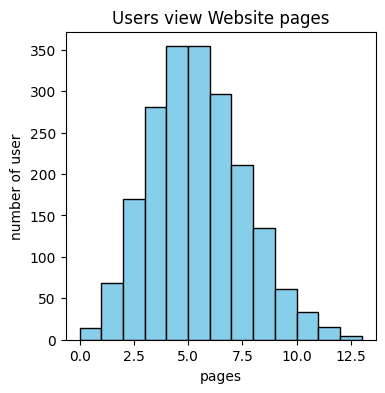

In [10]:
#numarical columns ---page views

plt.figure(figsize=(4,4)) 


plt.hist(
   df['Page Views'],
   color ='skyblue',
   edgecolor = 'black',
    bins=range(0,14),
)
plt.ylabel("number of user")
plt.xlabel("pages")
plt.title("Users view Website pages")
plt.show()

### Observation / Insight ----page views

Observation

Around 700 users visited 4 to 6 pages on the website.

Around 500 users visited 0 to 4 pages on the website.

Around 800 users visited 6 to 14 pages on the website.

Insight

This indicates that a large number of users leave the website after visiting only a few pages.
Almost 1200 users did not visit more than 6 pages, which suggests that many users are not exploring the website deeply.


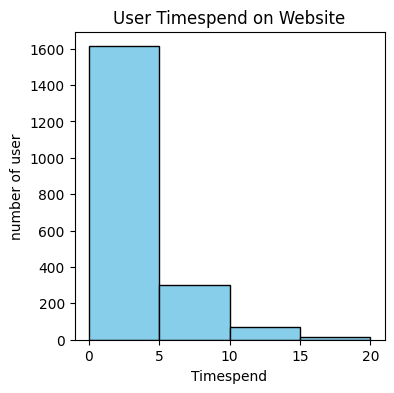

In [11]:
#numarical columns ---Session Durasion

plt.figure(figsize=(4,4)) 

bins = [0, 5,10, 15,20]
plt.hist(
   df['Session Duration'],
   color ='skyblue',
   edgecolor = 'black',
    bins=bins
)
plt.ylabel("number of user")
plt.xlabel("Timespend")
plt.title("User Timespend on Website")
plt.show()

### Observation / Insight ----Session Durasion Column

Most users spend 0-5 minutes on the website.

few users spend 5-10 minutes on the website.

Very few users spend more than 15 minutes.

This indicates that the majority of users leave the website quickly.

Almost 1,600 users left the website within 5 minutes.


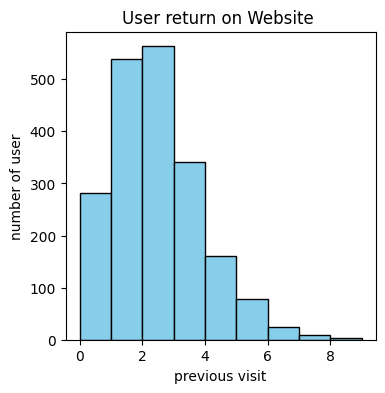

In [12]:
#numarical columns ---previous visit 

plt.figure(figsize=(4,4)) 


plt.hist(
   df['Previous Visits'],
   color ='skyblue',
   edgecolor = 'black',
    bins=range(0,10),
)
plt.ylabel("number of user")
plt.xlabel("previous visit")
plt.title("User return on Website ")
plt.show()

### Observation / Insight ----previous visits
Observation

Around 800 users have 0 or 1 previous visit out of 2000 users.

Around 1000 users have between 2 and 4 previous visits out of 2000 users.

Very few users (around 200) have more than 4 previous visits.

Insight

This indicates that around 800 users did not return to the website more than once, while a larger number of users visited the website multiple times.
 

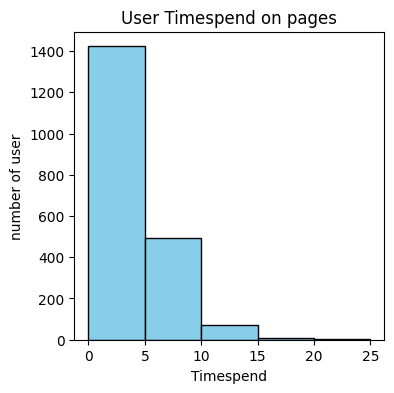

In [13]:
#numarical columns ---Time on Page

plt.figure(figsize=(4,4)) 

bins = [0, 5, 10,15,20,25]
plt.hist(
   df['Time on Page'],
   color ='skyblue',
   edgecolor = 'black',
    bins=bins
)
plt.ylabel("number of user")
plt.xlabel("Timespend")
plt.title("User Timespend on pages")
plt.show()

### Observation / Insight --- Time on Page Column

Most users spend 0-5 minutes on the website pages.something 1450 users

few users spend 5-10 minutes on the website pages.somthing 500 users 

Very few users spend more than 10 minutes on the website pages.something 50 users

This indicates that the majority of users leave the website pages quickly.

Almost 1,450 users left the pages within 5 minutes.

C:\Users\HP\AppData\Local\Temp\ipykernel_6844\3492848391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


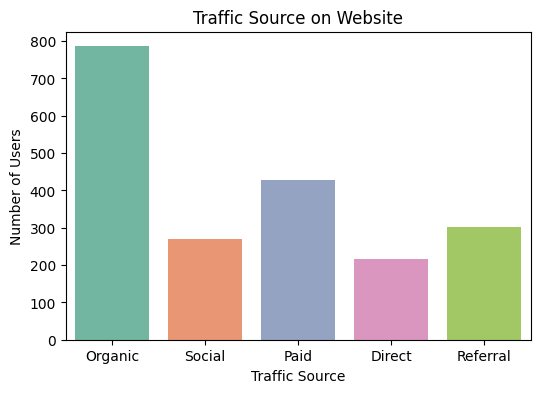

In [14]:
#Categorical colums --- Traffic Source
plt.figure(figsize=(6,4))

sns.countplot(
    x='Traffic Source',
    data=df,
    palette='Set2'
)

plt.title("Traffic Source on Website")
plt.xlabel("Traffic Source")
plt.ylabel("Number of Users")

plt.show()

### observation / insights ---Traffic source on website

Around 750 users come from organic Source like from google search.

Around 250 users come from social Source like from instagram, facebook.

Around 450 users come from paid Source like from google ads, social media ads instagram ads,facebook ads etc.

Around 200 users come from Direct Source like from website url , email .

Around 350 users come referral Source like from ather website link.



most of the user come from organicly that's good things as a startup website 

In [16]:
conversion_rate = df['Conversion Rate'].mean() * 100
print(conversion_rate)

98.20652906162547


In [17]:
df['Conversion Rate'].value_counts()

Conversion Rate
1.000000    1773
0.963080       1
0.868593       1
0.972277       1
0.892856       1
            ... 
0.791405       1
0.565124       1
0.997645       1
0.944066       1
0.947612       1
Name: count, Length: 228, dtype: int64

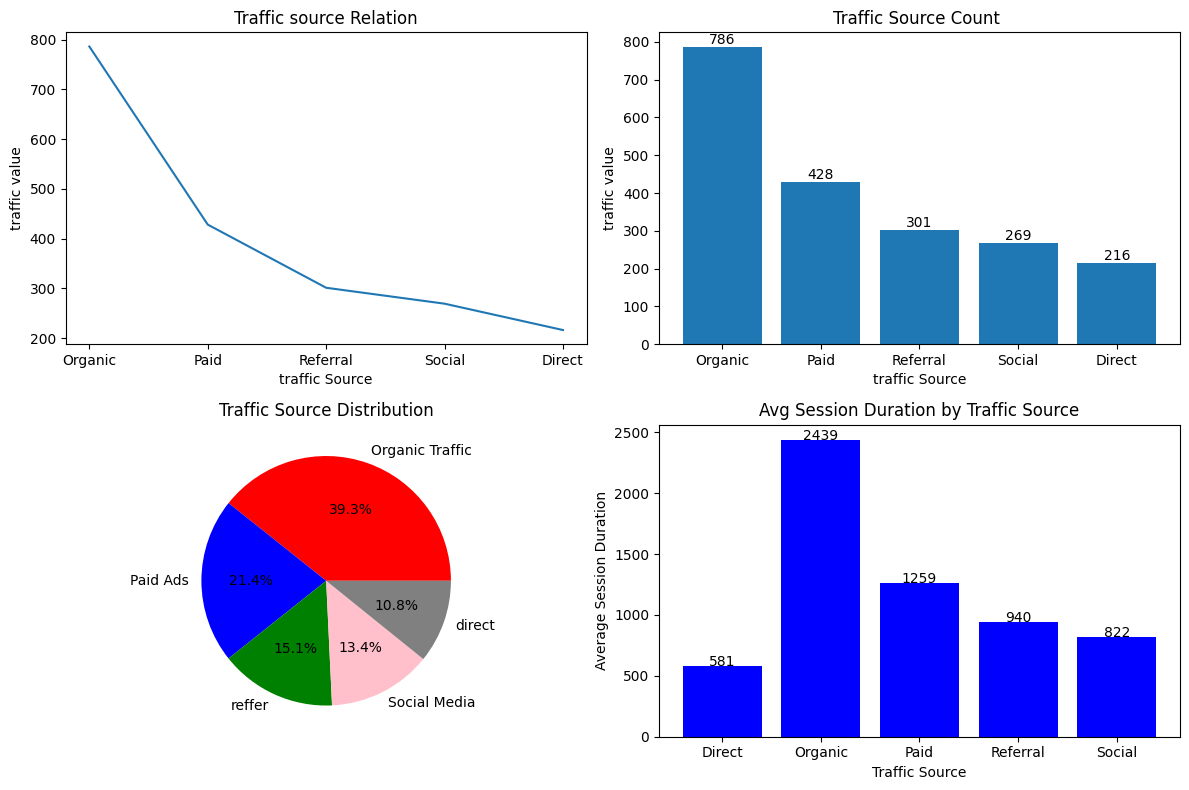

In [15]:
counts = df['Traffic Source'].value_counts()
visits = df.groupby('Traffic Source')['Session Duration'].sum()

plt.figure(figsize=(12,8)) 
plt.subplot(2,2,1)
plt.plot(counts.index, counts.values)  # line lpot 
plt.xlabel("traffic Source")
plt.ylabel("traffic value")
plt.title("Traffic source Relation")


plt.subplot(2,2,2)
plt.bar(counts.index,counts.values)   # bar plot 
plt.xlabel("traffic Source")
plt.ylabel("traffic value")
plt.title("Traffic Source Count ")

for i in range(len(counts)):
    plt.text(
        counts.index[i],
        counts.values[i],
        counts.values[i],
        ha='center',
        va='bottom'
    )
    
plt.subplot(2,2,3)
label_map ={
   'Organic': 'Organic Traffic',
    'Social': 'Social Media',
    'Paid': 'Paid Ads',
    'Referral': 'reffer',
    'Direct': 'direct'
}
labels = [label_map[i] for i in counts.index]
plt.pie(counts.values,labels=labels, autopct = '%1.1f%%', colors=["red", "blue", "green", "pink","grey"]) # pie plot 
plt.title('Traffic Source Distribution')

plt.subplot(2,2,4)
plt.bar(visits.index, visits.values , color="blue")      #bar plot 
plt.xlabel("Traffic Source")
plt.ylabel("Average Session Duration")
plt.title("Avg Session Duration by Traffic Source")

for i in range(len(counts)):
    plt.text(
        visits.index[i],      # x position
        visits.values[i],     # y position
       int(visits.values[i]),     # label value flote to integer
        ha='center',
    ) 

plt.tight_layout()


### EDA for (bivariate and multivariate)

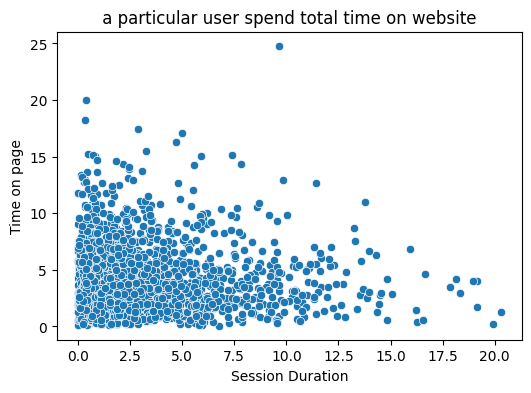

In [13]:
# users spend total time on website ----numarical colums (session Duration , Time on Page )

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Session Duration'],y=df['Time on Page'])

plt.xlabel('Session Duration')
plt.ylabel('Time on page')
plt.title(' a particular user spend total time on website ')
plt.show()

In [18]:
df[["Conversion Rate", "Previous Visits"]].corr()

,Conversion Rate,Previous Visits
Conversion Rate,1.000000,0.109496
Previous Visits,0.109496,1.000000


In [22]:
# Step 1: Total Time
df['Timespend'] = ((df['Session Duration']+ df['Time on Page']))
df.drop(columns=['Session Duration', 'Time on Page'], inplace=True)

# Step 2: Return target using last 1 month previous visits
df["Return"] = (df["Previous Visits"] > 1).astype(int)

# Step 3: Drop irrelevant columns
df = df.drop(columns=['Bounce Rate', 'Conversion Rate'],axis=1)


df = df[df['Traffic Source'].isin(['Paid', 'Organic', 'Social'])]


df = pd.get_dummies(df, columns=['Traffic Source'], drop_first=True , dtype='uint8')


In [23]:
df.head(5)

,Page Views,Previous Visits,Timespend,Return,Traffic Source_Paid,Traffic Source_Social
0,5,3,14.941841,1,0,0
1,4,0,11.907490,0,0,1
2,4,2,11.257222,1,0,0
3,5,3,5.701204,1,0,0
4,5,5,6.196497,1,1,0


In [27]:
percentages = df['Return'].value_counts(normalize=True) * 100
print(percentages)

Return
1    59.069454
0    40.930546
Name: proportion, dtype: float64


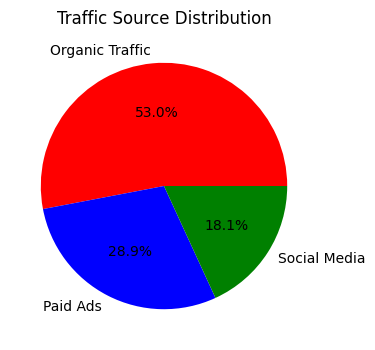

In [15]:
plt.figure(figsize=(4,4)) 
counts = df['Traffic Source'].value_counts()


label_map = {
    'Organic': 'Organic Traffic',
    'Social': 'Social Media',
    'Paid': 'Paid Ads'
  
}

labels = [label_map[i] for i in counts.index]

plt.pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=["red", "blue", "green"]
)

plt.title('Traffic Source Distribution')
plt.show()


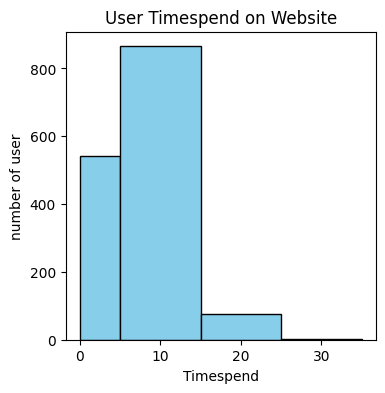

In [17]:
plt.figure(figsize=(4,4)) 

bins = [0, 5, 15,25,35]
#labels = ['veryLow (0-5)min', 'midlow (5-10)min', 'low(10-15)min', 'mid(15-20)min','high(20-25)','midhigh(25-30)','veryhigh(30-35)']
plt.hist(
   df['Timespend'],
   color ='skyblue',
   edgecolor = 'black',
    bins=bins,
    #labels=labels
)
plt.ylabel("number of user")
plt.xlabel("Timespend")
plt.title("User Timespend on Website")
plt.show()

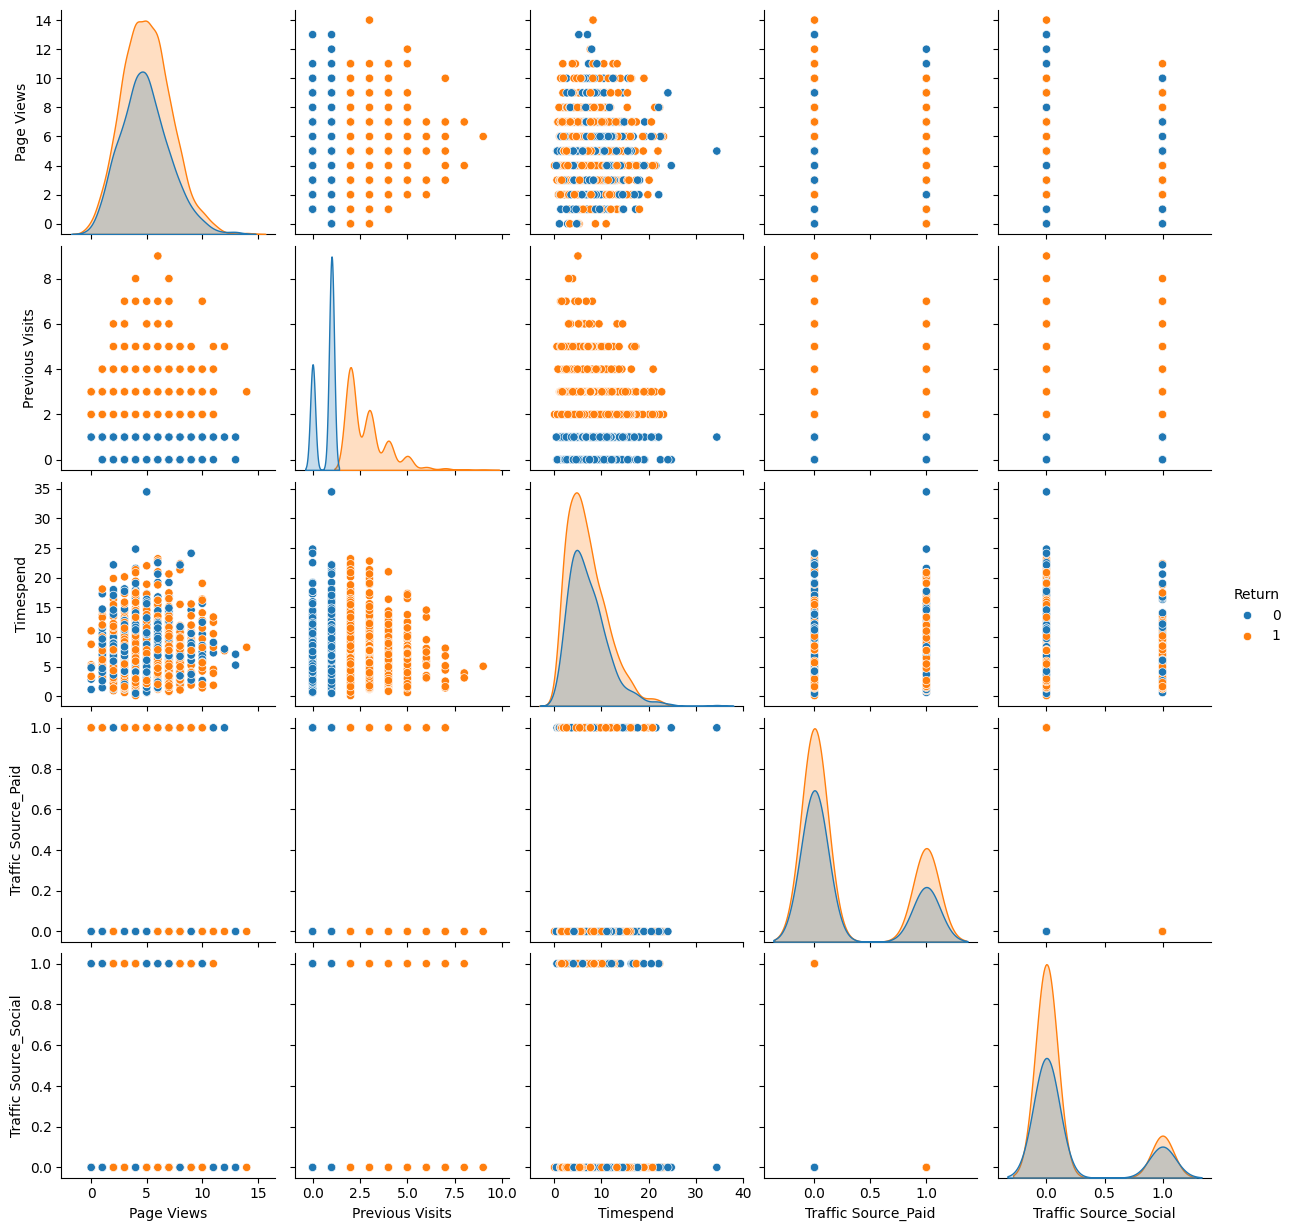

In [24]:
sns.pairplot(df, hue='Return')

In [25]:
df.corr()

,Page Views,Previous Visits,Timespend,Return,Traffic Source_Paid,Traffic Source_Social
Page Views,1.000000,0.031627,0.029304,0.033368,0.000562,-0.053547
Previous Visits,0.031627,1.000000,-0.052214,0.768821,0.028613,-0.046374
Timespend,0.029304,-0.052214,1.000000,-0.028036,-0.010141,0.016664
Return,0.033368,0.768821,-0.028036,1.000000,0.042925,-0.053016
Traffic Source_Paid,0.000562,0.028613,-0.010141,0.042925,1.000000,-0.299821
Traffic Source_Social,-0.053547,-0.046374,0.016664,-0.053016,-0.299821,1.000000


In [26]:
percentages = df['Return'].value_counts(normalize=True) * 100
print(percentages)

Return
1    59.069454
0    40.930546
Name: proportion, dtype: float64


### this is better than previous plot because it is shows right color for right value with label.

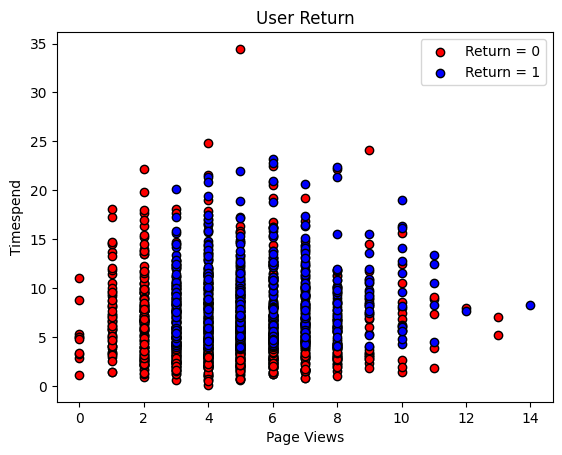

In [17]:
import matplotlib.pyplot as plt

# Split data by Return value
df0 = df[df['Return'] == 0]
df1 = df[df['Return'] == 1]

plt.scatter(
    df0['Page Views'],
    df0['Timespend'],
    color='red',
    label='Return = 0',
    edgecolors='k'
)

plt.scatter(
    df1['Page Views'],
    df1['Timespend'],
    color='blue',
    label='Return = 1',
    edgecolors='k'
)

plt.xlabel('Page Views')
plt.ylabel('Timespend')
plt.title('User Return')
plt.legend()
plt.show()



In [16]:
percentages = df['Return'].value_counts(normalize=True) * 100
print(percentages)

Return
0    61.699258
1    38.300742
Name: proportion, dtype: float64


In [19]:
df.head()

,Page Views,Previous Visits,Timespend,Traffic Source_Paid,Traffic Source_Social,Return
0,5,3,14.941841,0,0,1
1,4,0,11.907490,0,1,0
2,4,2,11.257222,0,0,1
3,5,3,5.701204,0,0,1
4,5,5,6.196497,1,0,1


In [ ]:
# that is the way to define x and y 
# X = df[["Page Views", "Previous Visits", "Timespend","Traffic Source_Paid","Traffic Source_social"]]
# y = df["Return"]

In [17]:
X = df.drop("Return", axis=1)
y = df["Return"]

In [18]:
# train test split 

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

In [19]:
# feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Model
model = LogisticRegression(penalty='l2',
    C= 0.1,
    solver='liblinear',
    max_iter=200,
    class_weight='balanced',
    random_state=42
)


In [21]:
# Train
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,200
,multi_class,'deprecated'


In [22]:
# Predict train data
y_train_pred = model.predict(X_train)

In [23]:
#predict test data 

y_test_pred = model.predict(X_test)

In [24]:
#check Accuracy score 

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.7883642495784149
Test Accuracy: 0.7845117845117845


In [25]:
print(model.coef_)
print(model.intercept_)

[[0.52103313 1.55286987 0.8305208  0.03123212 0.04414376]]
[-0.18437799]


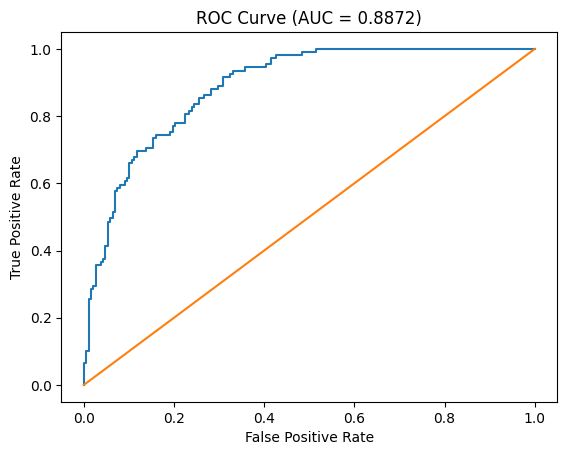

AUC Score: 0.8872242826468866


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Probability predictions (positive class ke liye)
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
roc_auc = auc(fpr,tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

print("AUC Score:", roc_auc)

In [ ]:
#model.predict_proba(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']  # supports l1 and l2
}

grid = GridSearchCV(
    LogisticRegression(max_iter=200),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

In [113]:
#Prediction 

new_data = np.array([[2, 2, 100, 1, 0]])

In [114]:
new_data = scaler.transform(new_data)

c:\NUMPY_YT\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [115]:
prediction = model.predict(new_data)
print(prediction)

[1]
